In [2]:
import pandas as pd

/tmp/ipykernel_2496903/4080736814.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
# seed3つの平均スコアを計算する関数
def get_avg_score(df):
    df["model"] = df["name"].str.replace(r"_seed\d+", "", regex=True)
    df_avg=df.groupby("model").mean(numeric_only=True).reset_index()
    return df_avg

In [4]:
# mlpのparamsを計算する関数
def mlp_params(input_dim,output_dim):
    # hidden size 1024, layers 2
    hidden_size = 1024
    layer1 = (input_dim * hidden_size) + hidden_size
    layer2 = (hidden_size * hidden_size) + hidden_size
    layer3 = (hidden_size * output_dim) + output_dim
    params = layer1 + layer2 + layer3
    return params

In [5]:
# rnnのparamsを計算する関数
def rnn_params(input_dim,output_dim):
    # hidden size 400, layers 2, LSTM Cell
    hidden_size = 400
    layer1 = 4 * ((input_dim + hidden_size) * hidden_size + hidden_size)
    layer2 = 4 * ((hidden_size + hidden_size) * hidden_size + hidden_size)
    layer3 = (hidden_size * output_dim) + output_dim
    params = layer1 + layer2 + layer3
    return params

In [6]:
# ncpのparamsを計算する関数
def ncp_params(input_dim, output_dim, units):
    layer1 = (input_dim * units) + units
    params_1 = units * 3 #gleak,vleak,cm
    params_2 = units * units * 5 # sigma, mu, w, erev, sparsity_mask
    params_3 = input_dim * units * 5 # sensory_sigma, sensory_mu, sensory_w, sensory_erev, sensory_sparsity_mask
    layer2 = (units * output_dim) + output_dim
    params = layer1 + params_1 + params_2 + params_3 + layer2
    return params

In [7]:
import re
def calculate_model_size(df, task):
    df = df.copy()
    if task == "lift": #[10,3,4,2]
        input_dim = 19
        output_dim = 7
    elif task == "can": #[14,3,4,2]
        input_dim = 23
        output_dim = 7
    elif task == "square": #[14,3,4,2]
        input_dim = 23
        output_dim = 7
    else:
        raise ValueError("Unknown task")
    for model in df["model"].unique():
        idx = df["model"] == model
        if model == "bc-pure":
            df.loc[idx, "params"] = mlp_params(input_dim,output_dim)
        elif model == "bc-rnn-pure":
            df.loc[idx, "params"] = rnn_params(input_dim,output_dim)
        elif model.startswith("ncp"):
            u = int(re.search(r"_u(\d+)", model).group(1))
            df.loc[idx, "params"] = ncp_params(input_dim,output_dim,u)
        else:
            raise ValueError("Unknown model")
    return df

In [8]:
df_lift=pd.read_csv('/work/robomimic/csv/lift/lift-best.csv')
df_can=pd.read_csv('/work/robomimic/csv/can/can-best.csv')
df_square=pd.read_csv('/work/robomimic/csv/square/square-best.csv')
df_can_avg=get_avg_score(df_can)
df_can_avg=calculate_model_size(df_can_avg, "can")
df_lift_avg=get_avg_score(df_lift)
df_lift_avg=calculate_model_size(df_lift_avg, "lift")
df_square_avg=get_avg_score(df_square)
df_square_avg=calculate_model_size(df_square_avg, "square")

In [9]:
print(df_square_avg[["model","params","return","avg_policy_latency_ms", "avg_gpu_memory_increase_mb"]])

           model     params    return  avg_policy_latency_ms  \
0        bc-pure  1081351.0  0.390000               0.875822   
1    bc-rnn-pure  1962807.0  0.670000               1.152379   
2  ncp_u128_best   100999.0  0.453333               1.355979   
3  ncp_u256_best   365831.0  0.600000               1.042837   
4  ncp_u512_best  1387015.0  0.566667               1.056882   

   avg_gpu_memory_increase_mb  
0                   25.626953  
1                   39.490214  
2                    1.341309  
3                    4.924805  
4                   18.841797  


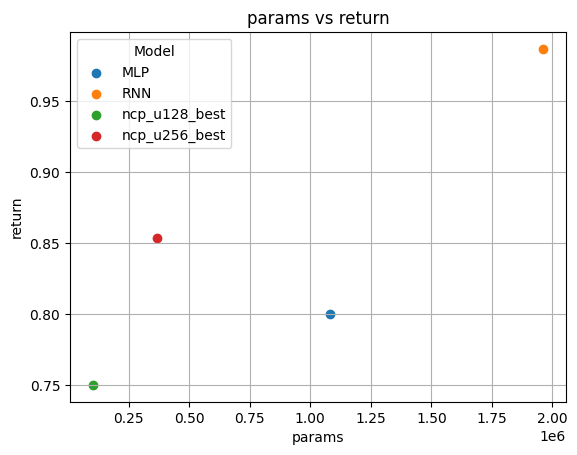

In [ ]:
import matplotlib.pyplot as plt

model_display_names = {
    "bc-pure": "MLP",
    "bc-rnn-pure": "RNN",
    "ncp_u256": "NCP-256neurons",
    "ncp_u512": "NCP-512neurons",
}

plt.figure()

for model in df_can_avg["model"].unique():
    df_m = df_can_avg[df_can_avg["model"] == model]
    display_name = model_display_names.get(model, model)
    plt.scatter(df_m["params"], df_m["return"], label=display_name)

plt.xlabel("params")
plt.ylabel("return")
plt.title("params vs return")
plt.legend(title="Model")
plt.grid(True)
plt.show()

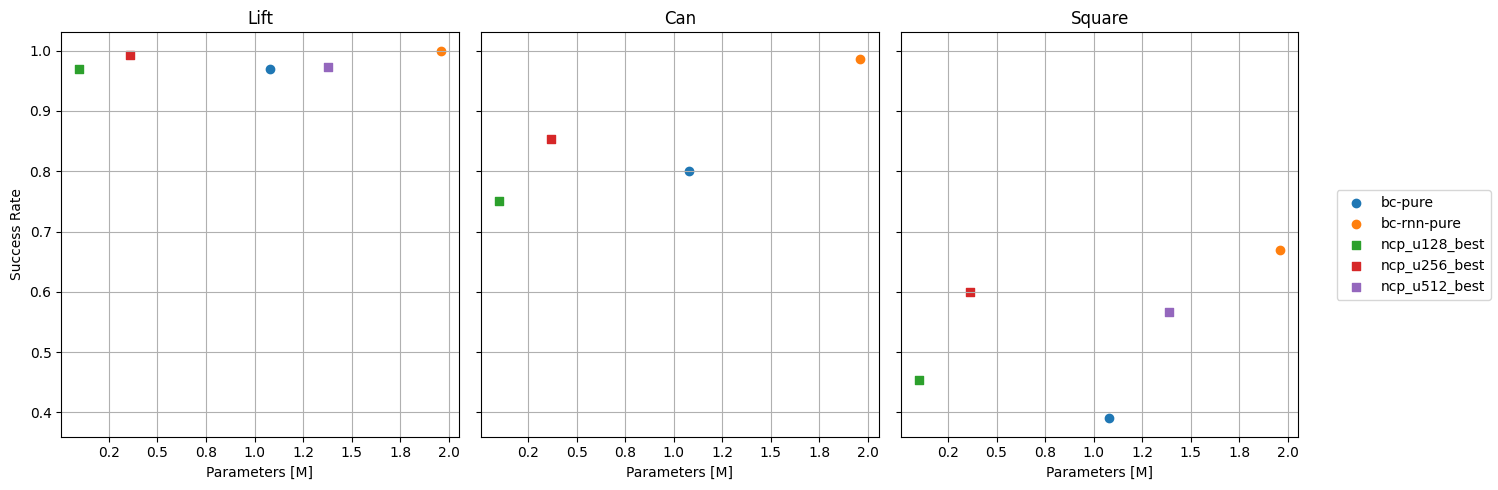

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

datasets = {
    "Lift": df_lift_avg,
    "Can": df_can_avg,
    "Square": df_square_avg
}

# モデルごとの色とマーカー設定
model_styles = {}
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

def get_style(model):
    if model not in model_styles:
        color = colors[len(model_styles) % len(colors)]
        marker = "s" if "ncp" in model.lower() else "o"  # ncpは四角
        model_styles[model] = {"color": color, "marker": marker}
    return model_styles[model]

for ax, (title, df) in zip(axes, datasets.items()):
    for model in df["model"].unique():
        sub = df[df["model"] == model]
        style = get_style(model)

        ax.scatter(
            sub["params"],
            sub["success_rate"],
            label=model,
            color=style["color"],
            marker=style["marker"]
        )

    ax.set_title(title)
    ax.set_xlabel("Parameters [M]")
    ax.grid(True)

# y軸は success rate
axes[0].set_ylabel("Success Rate")

# x軸を M 表記に変換
for ax in axes:
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}")
    )

# 凡例は右側にまとめて配置
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", frameon=True)

plt.tight_layout(rect=[0, 0, 0.88, 1])  # 凡例スペース確保
plt.show()
